In [1]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer

/Users/krish/Downloads/MindScope/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../data/processed/final_corpus.csv")

print(df.shape)
df.head()

(82872, 3)


,text,clean_text,processed_text
0,My favourite food is anything I didn't have to...,my favourite food is anything i didn t have to...,favourite food didn cook
1,"Now if he does off himself, everyone will thin...",now if he does off himself everyone will think...,think have laugh screw people instead actually...
2,WHY THE FUCK IS BAYLESS ISOING,why the fuck is bayless isoing,fuck bayless isoing
3,To make her feel threatened,to make her feel threatened,feel threaten
4,Dirty Southern Wankers,dirty southern wankers,dirty southern wanker


In [49]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("BAAI/bge-base-en-v1.5")
print("model loaded")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6238.82it/s]


model loaded


In [50]:
sample_df = df.reset_index(drop=True)

print(sample_df.shape)

(82872, 3)


In [51]:
texts = sample_df["processed_text"].tolist()

embeddings = model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True
)

print(embeddings.shape)

Batches: 100%|██████████| 1295/1295 [10:11<00:00,  2.12it/s]  


(82872, 768)


In [46]:
import umap.umap_ as umap

In [52]:
import umap

reducer = umap.UMAP(
    n_neighbors=25,
    min_dist=0.05,
    metric="cosine",
    random_state=42
)

embedding_2d = reducer.fit_transform(embeddings)

print(embedding_2d.shape)

/Users/krish/Downloads/MindScope/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(82872, 2)


In [8]:
import hdbscan

In [53]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=80,
    min_samples=20,
    metric="euclidean",
    prediction_data=True
)

labels = clusterer.fit_predict(embedding_2d)

sample_df["cluster"] = labels

print("Clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise:", sum(labels == -1))

Clusters: 20
Noise: 1728


In [57]:
from collections import Counter
import re

STOPWORDS = {
    "feel","feeling","felt","like","want","need","know","think",
    "time","good","life","find","help","people","really","make",
    "thing","things","going","something","would","could","much",
    "also","still","even","well","thank","please","self"
}

cluster_names = {}

for c in sorted(sample_df.cluster.unique()):
    if c == -1:
        continue

    subset = sample_df[sample_df.cluster == c]

    text = " ".join(
        subset["processed_text"].astype(str).tolist()
    ).lower()

    words = re.findall(r"\b[a-z]{4,}\b", text)

    filtered = [
        w for w in words
        if w not in STOPWORDS
    ]

    common = [
        w for w, _ in Counter(filtered).most_common(12)
    ]

    cluster_names[c] = common

print("done")

done


In [73]:
for c in sorted(sample_df.cluster.unique()):
    if c == -1:
        continue

    subset = sample_df[sample_df.cluster == c]

    print("\n")
    print("="*80)
    print("CLUSTER", c)
    print("="*80)

    print("\nKEYWORDS:")
    print(", ".join(cluster_names[c][:12]))

    print("\nSAMPLES:")
    for s in subset["text"].sample(3, random_state=42):
        print("-", s[:220])



CLUSTER 0

KEYWORDS:
sexuality, sexual, identity, question, explore, lgbtq, struggle, orientation, understand, experience, navigate, acceptance

SAMPLES:
- I've been questioning my sexuality for a while now, and it's causing me a lot of confusion and distress. I've always identified as straight, but recently I've found myself attracted to people of the same gender. This rea
- Sexuality includes romantic attraction in its labeling and always has. Asexual folks are the only people who really need it.
- I've had these intrusive thoughts about my sexuality recently and it's been causing me a lot of distress. My goal in therapy is to understand why this is happening and find ways to manage these thoughts.
 
I have been st


CLUSTER 1

KEYWORDS:
child, parent, parenting, strategy, behavior, guidance, challenge, struggle, effective, overwhelmed, worry, support

SAMPLES:
- I've been struggling to balance my caregiving responsibilities with my own mental health. The demands of caring for my c

In [58]:
for k, v in cluster_names.items():
    print("\n" + "="*60)
    print(f"CLUSTER {k}")
    print("="*60)
    print(", ".join(v))


CLUSTER 0
sexuality, sexual, identity, question, explore, lgbtq, struggle, orientation, understand, experience, navigate, acceptance

CLUSTER 1
child, parent, parenting, strategy, behavior, guidance, challenge, struggle, effective, overwhelmed, worry, support

CLUSTER 2
love, look, year, right, come, work, little, pretty, great, didn, post, hope

CLUSTER 3
addiction, substance, abuse, alcohol, control, overcome, struggle, symptom, drug, relationship, break, counseling

CLUSTER 4
change, behavior, habit, healthy, behavioral, pattern, develop, strategy, break, struggle, food, goal

CLUSTER 5
anxiety, fear, thought, situation, manage, symptom, experience, social, worry, trigger, counseling, panic

CLUSTER 6
overwhelmed, little, come, list, start, completely, teacher, lately, stress, today, sure, trust

CLUSTER 7
stress, work, manage, pressure, counseling, level, symptom, strategy, constant, experience, healthy, technique

CLUSTER 8
professional, ethical, legal, situation, navigate, dilem

In [59]:
sample_df["x"] = embedding_2d[:, 0]
sample_df["y"] = embedding_2d[:, 1]

sample_df.to_csv("../models/clustered_data.csv", index=False)

print("saved clustered_data.csv")

saved clustered_data.csv


In [32]:
import plotly.express as px

fig = px.scatter(
    sample_df,
    x="x",
    y="y",
    color=sample_df["cluster"].astype(str),
    hover_data=["text"],
    title="MindScope Emotional Language Clusters"
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [60]:
np.save("../models/embeddings.npy", embeddings)
print("saved embeddings.npy")

saved embeddings.npy


In [61]:
np.save("../models/embedding_2d.npy", embedding_2d)
print("saved embedding_2d.npy")

saved embedding_2d.npy


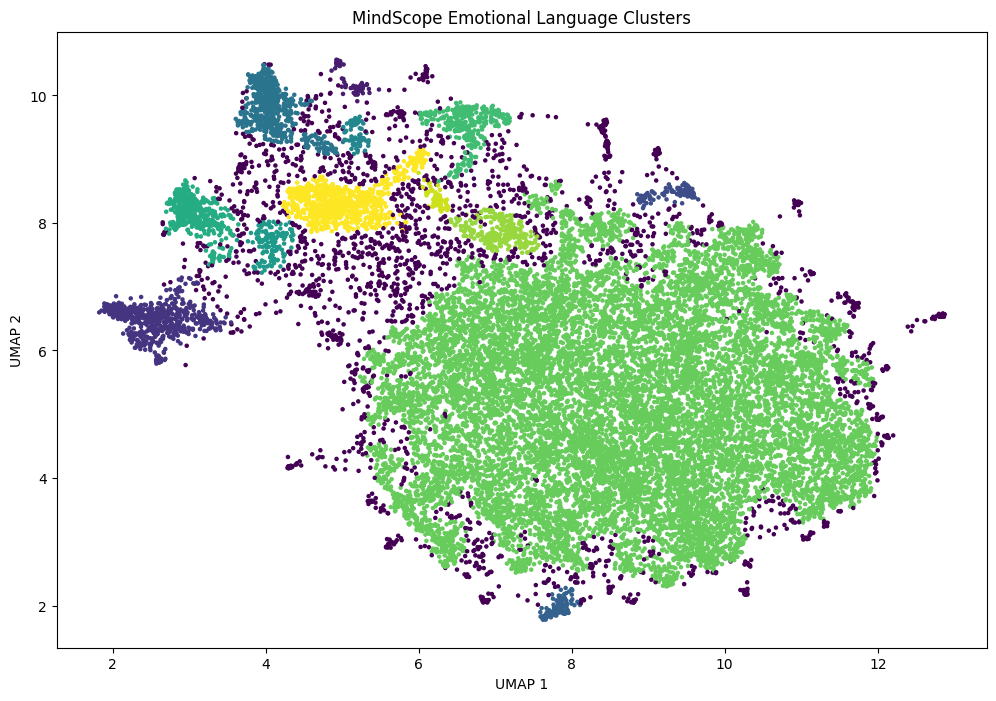

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    sample_df["x"],
    sample_df["y"],
    c=sample_df["cluster"],
    s=5
)

plt.title("MindScope Emotional Language Clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

In [62]:
model.save("../models/sentence_model")
print("saved sentence_model")

Writing model shards: 100%|██████████| 1/1 [00:19<00:00, 19.25s/it]


saved sentence_model


In [63]:
print("Clusters found:", len(set(labels)))
print("Noise points:", sum(labels == -1))

Clusters found: 21
Noise points: 1728


In [64]:
for cluster_id in sorted(sample_df["cluster"].unique()):
    print("\n" + "="*60)
    print("CLUSTER:", cluster_id)
    print("="*60)

    examples = sample_df[sample_df["cluster"] == cluster_id]["text"].sample(
        min(10, len(sample_df[sample_df["cluster"] == cluster_id])),
        random_state=42
    )

    for ex in examples:
        print("-", ex)


CLUSTER: -1
- My depression has been triggered by recent major life changes, such as losing my job and going through a breakup. These events have left me feeling hopeless, worthless, and overwhelmed with grief. It's hard to see any light at the end of the tunnel.
- It feels as though I am trapped in a never-ending cycle of sadness and hopelessness. I struggle to find motivation or joy in anything, and even the simplest tasks feel exhausting. This has caused me to withdraw from social activities and isolate myself. My goal for this counseling session is to discover ways to break out of this cycle and start living a more fulfilling life.
- How can I better manage the negative thoughts that constantly plague my mind? They often spiral out of control and make me feel even more trapped in my depression.
- I've been struggling with behavioral change for a while now, and I hope that through this counseling session, I can find the motivation and tools to make positive changes in my life. Curr

In [65]:
sample_df["cluster"].value_counts()

cluster
 2     66165
 17     5978
 5      2736
-1      1728
 7      1561
 14     1156
 19      691
 18      679
 11      364
 1       283
 0       244
 16      191
 4       174
 8       162
 9       149
 13      117
 3       116
 6       104
 15       98
 10       95
 12       81
Name: count, dtype: int64

In [66]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

In [67]:
def get_top_words(df, cluster_id, n=10):
    texts = df[df["cluster"] == cluster_id]["processed_text"]

    if len(texts) < 5:
        return []

    vectorizer = CountVectorizer(
        stop_words="english",
        max_features=5000
    )

    X = vectorizer.fit_transform(texts)

    word_counts = np.asarray(X.sum(axis=0)).ravel()

    words = np.array(vectorizer.get_feature_names_out())

    top_idx = word_counts.argsort()[::-1][:n]

    return words[top_idx]

In [68]:
for cid in sorted(sample_df["cluster"].unique()):
    if cid == -1:
        continue

    print("\n" + "="*70)
    print(f"CLUSTER {cid}")
    print("="*70)

    print("Keywords:")
    print(", ".join(get_top_words(sample_df, cid)))

    print("\nSample texts:")
    samples = sample_df[sample_df["cluster"] == cid]["text"].sample(
        min(3, len(sample_df[sample_df["cluster"] == cid])),
        random_state=42
    )

    for s in samples:
        print("-", s[:200])


CLUSTER 0
Keywords:
sexuality, sexual, feel, self, identity, question, explore, feeling, lgbtq, struggle

Sample texts:
- I've been questioning my sexuality for a while now, and it's causing me a lot of confusion and distress. I've always identified as straight, but recently I've found myself attracted to people of the s
- Sexuality includes romantic attraction in its labeling and always has. Asexual folks are the only people who really need it.
- I've had these intrusive thoughts about my sexuality recently and it's been causing me a lot of distress. My goal in therapy is to understand why this is happening and find ways to manage these though

CLUSTER 1
Keywords:
child, parent, parenting, feel, strategy, want, behavior, guidance, challenge, struggle

Sample texts:
- I've been struggling to balance my caregiving responsibilities with my own mental health. The demands of caring for my children, combined with my own emotional needs, have left me feeling drained and 
- As a new parent, 

In [69]:
import os

os.makedirs("../models", exist_ok=True)

sample_df.to_csv("../models/clustered_data.csv", index=False)

print("saved clustered_data.csv")

saved clustered_data.csv


In [70]:
np.save("../models/embeddings.npy", embeddings)

print("saved embeddings.npy")

saved embeddings.npy


In [71]:
np.save("../models/embedding_2d.npy", embedding_2d)

print("saved embedding_2d.npy")

saved embedding_2d.npy


In [72]:
model.save("../models/sentence_model")

print("saved model")

Writing model shards: 100%|██████████| 1/1 [00:18<00:00, 18.60s/it]

saved model
